# Melanoma Classification using Computer Vision and Machine Learning

**INTRODUCTION**

Melanoma is one of the most aggressive forms of skin cancer, with survival Melanoma is one of the most aggressive forms of skin cancer, where early detection is critical for improving patient outcomes. However, distinguishing malignant lesions from benign ones is challenging due to subtle visual differences and extreme class imbalance in medical datasets.

In this project, I developed a hybrid classification pipeline that combines computer vision and traditional machine learning techniques. Image features were extracted using a pretrained convolutional neural network (ResNet), then integrated with patient metadata to create a unified feature space for modeling.

A key challenge in this dataset is the severe class imbalance (~2% melanoma cases), which makes standard accuracy metrics misleading. To address this, I evaluated multiple imbalance handling strategies and optimized the model for recall, prioritizing the correct identification of malignant cases.

The final model demonstrates how combining deep learning–based feature extraction with structured data can improve performance in high-risk classification problems, while highlighting the trade-offs between recall and precision in medical decision-making.

## Import Libraries

In [1]:
# General Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# To print multiple outputs
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

# Image and Directory
import os
from PIL import Image

# TensorFlow / Keras for pretrained CNN
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, InceptionV3
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_effnet
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_incep
from tensorflow.keras.preprocessing import image

# Torch for Image Features Extraction
import torchvision.transforms as transforms
from itertools import islice
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.datasets import DatasetFolder
from torchvision.datasets.folder import default_loader

# Data Cleaning
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Data Preparation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline

# Model Building and Evaluation
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, balanced_accuracy_score, make_scorer

## Data Understanding & Challenges

The dataset consists of 33,126 dermoscopic images from the ISIC 2020 challenge, accompanied by patient-level metadata.

This is a **multimodal dataset**, combining:
- medical images (lesion scans)
- structured clinical data (age, sex, anatomical site)

**Key Characteristics**
- Severe class imbalance (~98% benign, ~2% malignant)
- Multimodal structure (image data + tabular metadata)
- Missing values in clinical features (age, sex, anatomical site)

**Core Challenge**

The extreme class imbalance makes accuracy an unreliable metric, as models can achieve high accuracy by predicting only the majority class.

This requires:
- prioritizing **recall for melanoma detection**
- using evaluation metrics such as **PR-AUC and balanced accuracy**
- applying targeted imbalance handling strategies during modeling

### Data Acquisition Strategy

Due to the large size of the ISIC 2020 image dataset (~20GB), a dynamic data loading approach was used instead of storing the full dataset locally.

Images are downloaded and extracted within the runtime environment as needed. This approach ensures:
- Efficient use of storage and memory
- Reproducibility of the pipeline in cloud environments (e.g., Google Colab)
- Scalability for handling large computer vision datasets

### Download Images

In [ ]:
'''
# Downloading JPEG Images
#!wget "https://isic-challenge-data.s3.amazonaws.com/2020/ISIC_2020_Training_JPEG.zip" -O train_jpeg.zip
'''

In [ ]:
'''
# Unzip and delete zip file
!unzip -q train_jpeg.zip -d train_images
!rm train_jpeg.zip
'''

'\n# Unzip and delete zip file\n!unzip -q train_jpeg.zip -d train_images\n!rm train_jpeg.zip\n'

In [ ]:
'''
# Check that the train_image file has all the images
image_count = 0
for root, dirs, files in os.walk("train_images"):
    image_count += len(files)

print("Total JPEG Images:", image_count)
'''

'\n# Check that the train_image file has all the images\nimage_count = 0\nfor root, dirs, files in os.walk("train_images"):\n    image_count += len(files)\n\nprint("Total JPEG Images:", image_count)\n'

 A validation check was performed to ensure all images were successfully extracted before proceeding to preprocessing and feature extraction.

### Load and Examine Metadata

In [2]:
# Read in the dataset
labels = pd.read_csv("ISIC_2020_Training_GroundTruth_v2.csv")
labels.head()


,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0


In [3]:
# Describe the data
labels.shape

labels.columns

(33126, 9)

Index(['image_name', 'patient_id', 'lesion_id', 'sex', 'age_approx',
       'anatom_site_general_challenge', 'diagnosis', 'benign_malignant',
       'target'],
      dtype='object')

In [4]:
# Check for missing values
labels.isnull().sum()

,0
image_name,0
patient_id,0
lesion_id,0
sex,65
age_approx,68
anatom_site_general_challenge,527
diagnosis,0
benign_malignant,0
target,0


In [5]:
# Check for duplicated values
labels.duplicated().sum()

np.int64(0)

In [6]:
# Check for class imbalance for target variable
labels.target.value_counts(normalize = True)

,proportion
target,
0,0.98237
1,0.01763


After looking at the data, we can see that the dataset has 33126 observations, and 9 variables:
- image_name: The code to identify the image
- patient_id: The patient's id
- lesion_id: The id assigned to the lesion in question for a patient
- sex: Male or Female
- age_approx: Patient's approximate age
- anatom_site_general_challenge: The anatomical site or location of the lesion
- diagnosis: The final result from tests done on the patient
- benign_malignant: Whether the lesion is benign or malignant
- target: Encoded version of benign_malignant<br><br>

The only three variables that are missing values are:
- age_approx: 68
- sex: 65
- anatom_site: 527

Additionally, the target variable is very severly imbalanced, with a 98/2 ratio for benign/malignant.



## Exploratory Data Analysis

To better understand the structure of the dataset and identify factors relevant to melanoma prediction, exploratory data analysis (EDA) was conducted on both categorical and numerical features.

A reusable helper class was implemented to standardize common EDA operations such as frequency tables, statistical summaries, and visualizations.

In [7]:
# EDA Helper Class

class EDAHelper:

    def freq_table(self, df, col):
        counts = [df[col].value_counts().values.tolist()]
        names = df[col].value_counts().keys()

        print("Frequency Table:")
        print(tabulate(counts, headers=names, tablefmt="pretty"))

    # --------------------------------------------

    def stats_table(self, df, col):
        var = df[col]

        names = ["Mean", "Min", "Max", "Median", "Std", "25%", "75%"]
        data = [[
            f"{var.mean():.3f}",
            f"{var.min():.3f}",
            f"{var.max():.3f}",
            f"{var.median():.3f}",
            f"{var.std():.3f}",
            f"{var.quantile(0.25):.3f}",
            f"{var.quantile(0.75):.3f}"
        ]]

        print("Statistics Table:")
        print(tabulate(data, headers=names, tablefmt="pretty"))

    # --------------------------------------------

    def histogram(self, df, col, x_min=None, x_max=None):
        plt.figure(figsize=(12, 8))
        sns.histplot(data=df, x=col, edgecolor='black')

        if x_min is not None and x_max is not None:
            plt.xlim(x_min, x_max)

        plt.title(f"{col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

    # --------------------------------------------

    def count_plot(self, df, col, rotation=0):
        plt.figure(figsize=(12, 8))
        sns.countplot(data=df, x=col, edgecolor='black')

        plt.title(f"{col} Distribution")
        plt.xticks(rotation=rotation)
        plt.show()

    # --------------------------------------------

    def box_plot(self, df, col):
        plt.figure(figsize=(12, 8))
        sns.boxplot(data=df, x=col)
        plt.title(f"{col} Boxplot")
        plt.show()


# Initialize helper
e = EDAHelper()

### Target Variable Analysis (Class Imbalance)

Understanding the distribution of the target variable is critical, as it directly impacts model design and evaluation.

Frequency Table:
+-------+-----+
|   0   |  1  |
+-------+-----+
| 32542 | 584 |
+-------+-----+


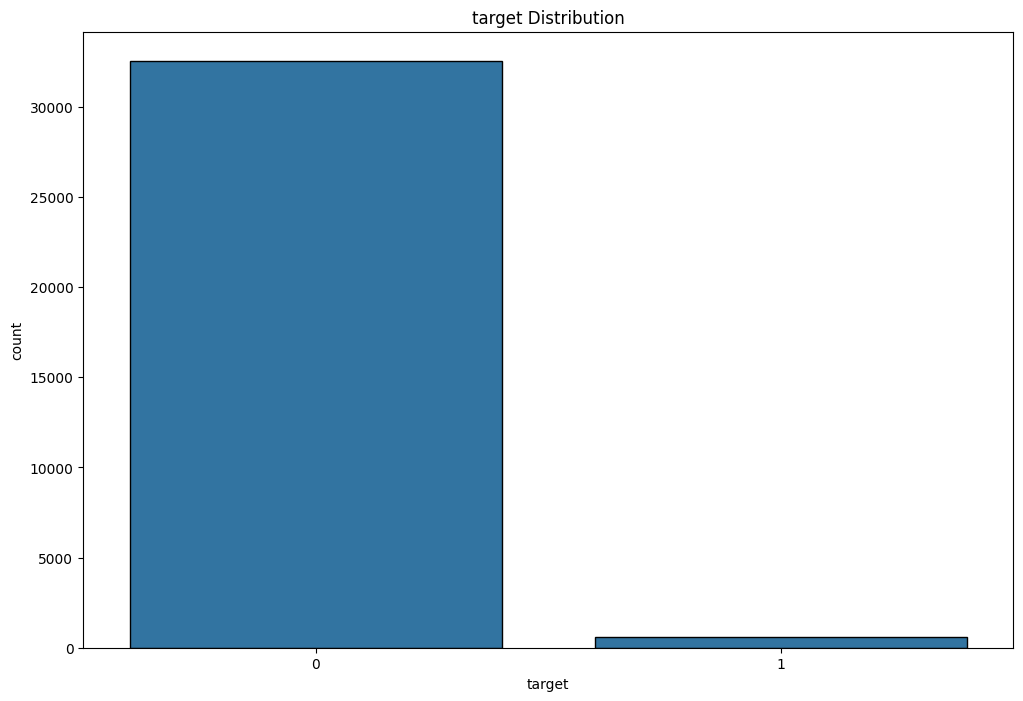

In [8]:
e.freq_table(labels, "target")
e.count_plot(labels, "target")

**Insight**

The dataset is extremely imbalanced, with melanoma cases representing approximately **2% of observations (~600 out of 33,126 samples)**.

**Implication**

- A naive model can achieve ~98% accuracy by predicting all samples as benign  
- Accuracy is therefore not a meaningful evaluation metric  
- The modeling strategy must prioritize:
  - **Recall (sensitivity)** to minimize missed melanoma cases  
  - **PR-AUC** for evaluating minority class performance  
  - **Balanced accuracy** to account for class imbalance  

This imbalance becomes the central challenge guiding all downstream modeling decisions.

### Demographic Features (Age & Sex)

Exploring patient demographics helps assess whether basic clinical variables carry predictive signal.

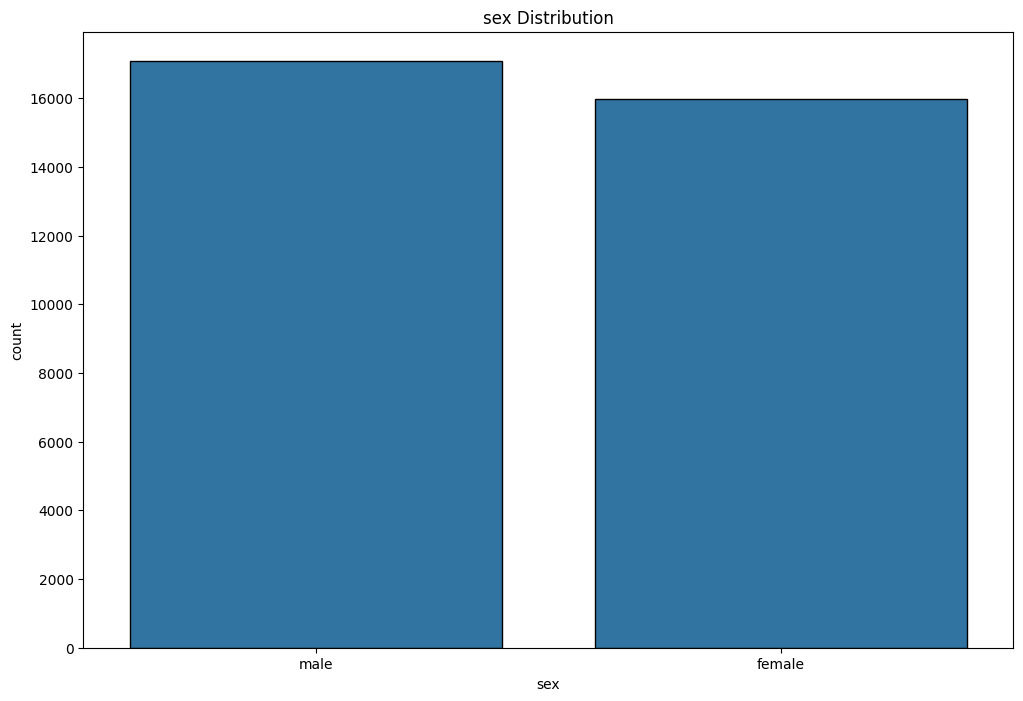

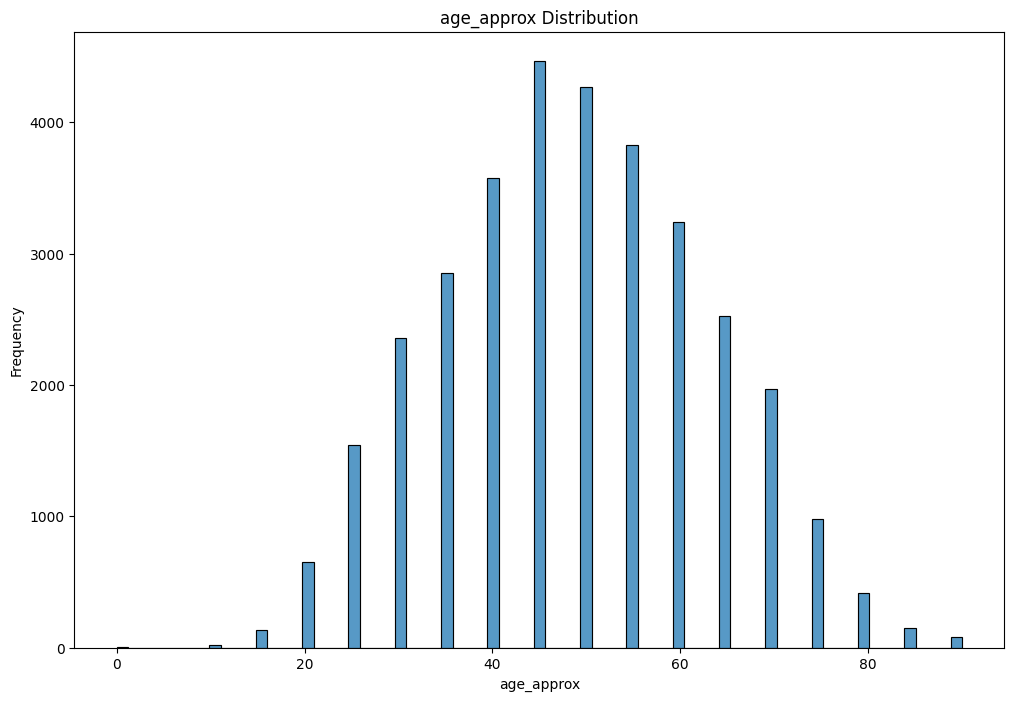

In [9]:
e.count_plot(labels, "sex")
e.histogram(labels, "age_approx")

**Insight**

- Patient ages are broadly distributed, with most cases between 25–75  
- Sex distribution is relatively balanced  

**Implication**

- Demographic features alone are unlikely to strongly distinguish melanoma cases  
- Their predictive value is likely **contextual**, contributing more when combined with image-based features  

### Anatomical Site Distribution

Understanding where lesions occur can provide clinically relevant signals.

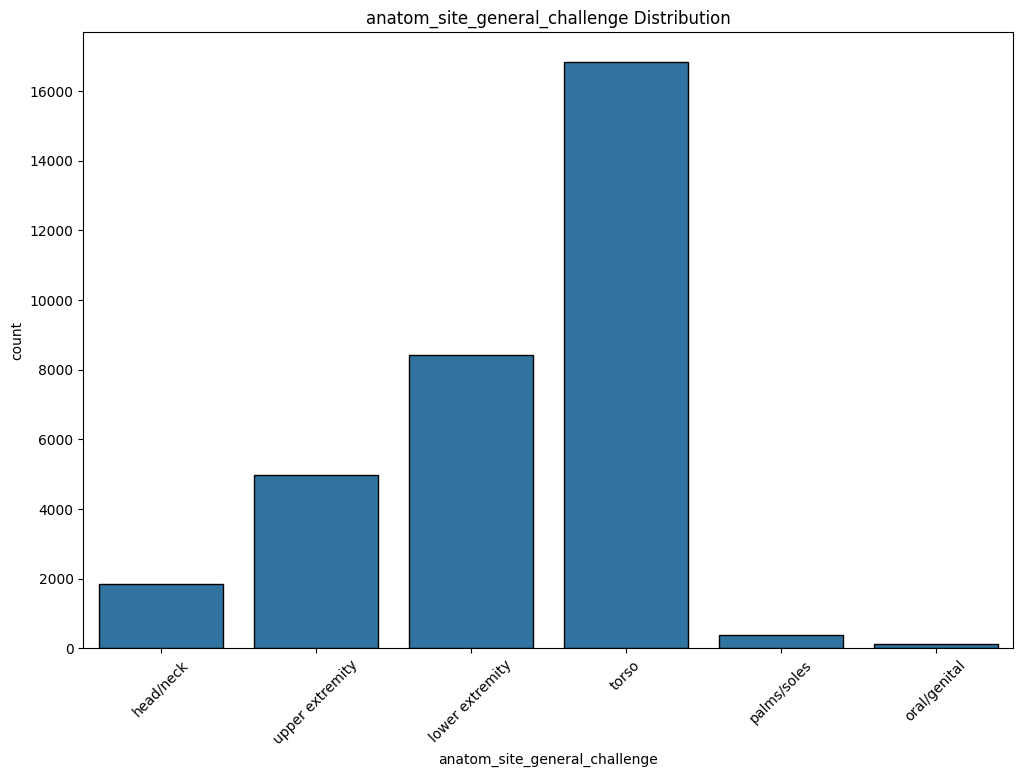

In [10]:
e.count_plot(labels, "anatom_site_general_challenge", rotation=45)

**Insight**

- Lesions most frequently appear on:
  - Torso  
  - Lower extremities  

**Implication**

- Anatomical location may contribute predictive signal  
- This feature should be retained and encoded rather than removed  
- Missing values should be handled carefully rather than dropped, as they may contain implicit clinical information  

### Diagnosis Distribution

The diagnosis variable provides more granular clinical categorization.

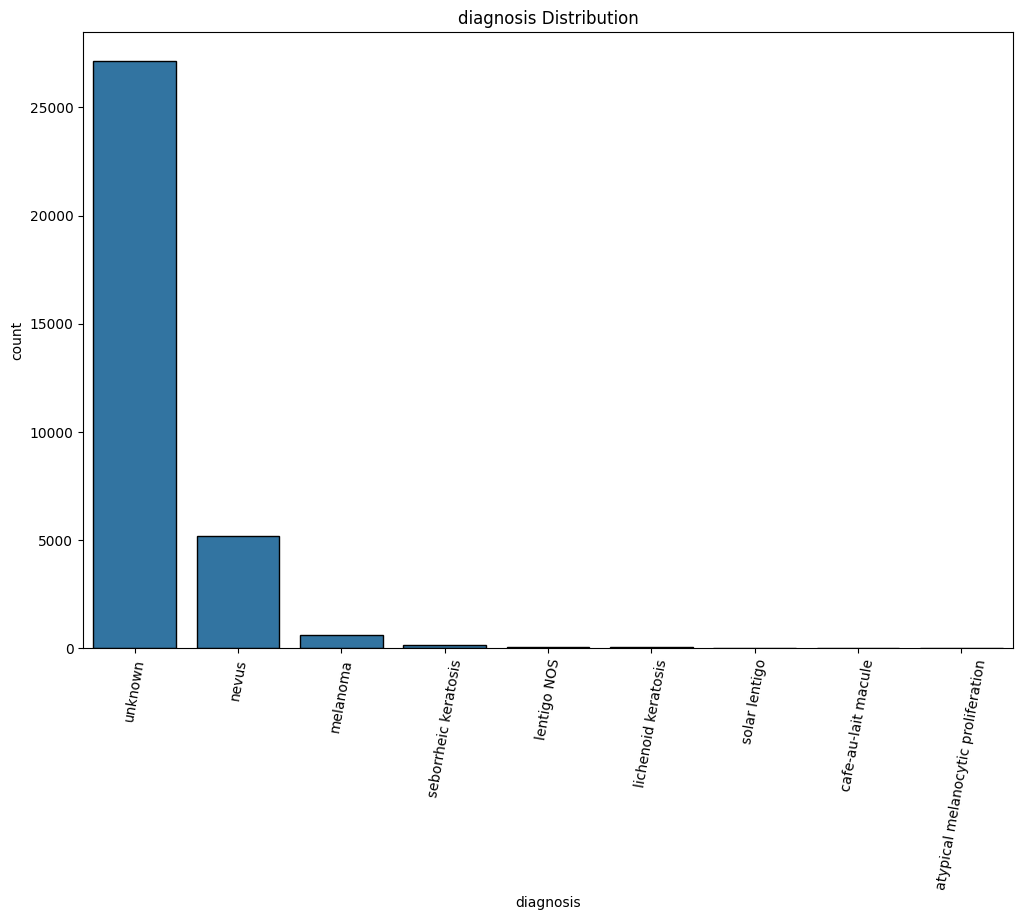

In [11]:
e.count_plot(labels, "diagnosis", rotation=80)

**Insight**

- Diagnosis categories are highly granular and unevenly distributed  

**Implication**

- High cardinality may introduce noise into the model  
- Feature engineering (grouping or encoding strategies) may be required  

### Target Validation

Before modeling, it is important to confirm consistency between raw labels and encoded targets.

In [12]:
e.freq_table(labels, "benign_malignant")

bm = labels["benign_malignant"].map({"benign": 0, "malignant": 1})
bm.corr(labels["target"])

Frequency Table:
+--------+-----------+
| benign | malignant |
+--------+-----------+
| 32542  |    584    |
+--------+-----------+


np.float64(0.9999999999999998)

**Insight**

- The encoded `target` variable is perfectly aligned with the original `benign_malignant` label  

**Implication**

- Confirms data integrity and absence of label inconsistencies  
- Ensures reliability of the target variable for modeling  

## Image Processing and Feature Extraction

### Linking Images to Metadata

To integrate image data with structured patient metadata, each record was mapped to its corresponding dermoscopic image using the image_name field.

In [13]:
# Identify target variable
target = "target"

# Create image path column
labels["image_path"] = labels["image_name"].apply(
    lambda x: f"train_images/train/{x}.jpg")

### Image Resolution Analysis

Before feature extraction, a sample of images was analyzed to understand variability in image dimensions.

In [39]:
'''
# Find the dimensions of each image

# Use a sample of the data as a test
sample_paths = labels["image_path"].sample(200, random_state=42)

# Create lists to get the size, width and height of each image
widths = []
heights = []
sizes = []

# Loop through each file path and open the image to get the dimensions
for path in sample_paths:
    img = Image.open(path)
    sizes.append(img.size)
    widths.append(img.width)
    heights.append(img.height)

# Print the size of the images
print(set(sizes))
'''

'\n# Find the dimensions of each image\n\n# Use a sample of the data as a test\nsample_paths = labels["image_path"].sample(200, random_state=42)\n\n# Create lists to get the size, width and height of each image\nwidths = []\nheights = []\nsizes = []\n\n# Loop through each file path and open the image to get the dimensions\nfor path in sample_paths:\n    img = Image.open(path)\n    sizes.append(img.size)\n    widths.append(img.width)\n    heights.append(img.height)\n\n# Print the size of the images\nprint(set(sizes))\n'

In [40]:
'''
# Use boxplot to see distribution of image widths and heights
# Widths
plt.figure(figsize = (8, 4))
sns.set_style('darkgrid')
sns.boxplot(x = widths)
plt.title("Width Outlier Detection")
plt.show()

# Heights
plt.figure(figsize=(8, 4))
sns.set_style('darkgrid')
sns.boxplot(x = heights)
plt.title("Height Outlier Detection")
plt.show()
'''

'\n# Use boxplot to see distribution of image widths and heights\n# Widths\nplt.figure(figsize = (8, 4))\nsns.set_style(\'darkgrid\')\nsns.boxplot(x = widths)\nplt.title("Width Outlier Detection")\nplt.show()\n\n# Heights\nplt.figure(figsize=(8, 4))\nsns.set_style(\'darkgrid\')\nsns.boxplot(x = heights)\nplt.title("Height Outlier Detection")\nplt.show()\n'

Boxplots were used to visualize the distribution of image widths and heights.

**Insight**

- Images vary in size, but without extreme outliers
- High resolution increases computational cost without necessarily improving model performance

**Implication**

- Standardizing image size is necessary for:
  - Efficient batch processing
  - Consistent feature extraction
  - Stable model inputs

### Image Feature Extraction

To extract meaningful representations from dermoscopic images, a **transfer learning approach** was used.

A pretrained **ResNet18 convolutional neural network** was used as a fixed feature extractor. This approach leverages representations learned from large-scale datasets (ImageNet), allowing the model to capture hierarchical visual patterns such as:

- Edges (early layers)
- Textures and shapes (mid layers)
- Complex structures (deep layers)

The final classification layer was removed, and the output of the penultimate layer was used as a feature embedding.


In [ ]:
'''
# Use GPU if available (cuda works because of Colab GPU option)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Resize + normalize (important for pretrained models)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                         std=[0.229, 0.224, 0.225])])

# Create a DatasetFolder object using paths from your dataframe
dataset = DatasetFolder(
    root=".",              # root folder is ignored here since we'll provide exact paths
    loader=default_loader, # function to load each image from file path
    is_valid_file = lambda x: True,  # every path is valid
    transform=transform    # apply the same transformations
)

# Override the dataset's samples with paths from your dataframe
# Each tuple is (image_path, label). Using 0 as a dummy label
dataset.samples = [(p, 0) for p in labels["image_path"]]

# Also set the targets (labels) to a list of zeros
dataset.targets = [0] * len(labels)


# Create data loader
loader = DataLoader(dataset,
                    batch_size = 128,
                    shuffle = False,
                    num_workers = 4,   # Parallel loading
                    pin_memory = True  # Faster GPU transfer
                    )

# Load pretrained ResNet18
model = models.resnet18(weights="DEFAULT")

# Remove final classification layer
model = torch.nn.Sequential(*list(model.children())[:-1])

model = model.to(device)
model.eval()

# Extract features
features = []
count = 1

with torch.no_grad():
    for images, _ in loader:
        images = images.to(device)
        print(count, images.device)
        count += 1
        outputs = model(images)
        outputs = outputs.view(outputs.size(0), -1)  # flatten
        features.append(outputs.cpu())

features = torch.cat(features)
print("Feature shape:", features.shape)
'''

**Output**

- Each image is represented as a 512-dimensional feature vector

**Insight**

- Transfer learning avoids expensive end-to-end training
- Pretrained CNN features provide strong general-purpose visual representations
- Efficient for tabular + image hybrid modeling

### Combine Image + Metadata

### Feature Persistence (Avoiding Reprocessing)

Due to the high computational cost of feature extraction, the generated feature matrix was saved and reused.


In [ ]:
'''
# Convert to numpy
features_np = features.numpy()

# Create feature column names for easier tracking
feature_cols = [f"img_feat_{i}" for i in range(features_np.shape[1])]

# Convert features to a dataframe
features_df = pd.DataFrame(features_np, columns = feature_cols)
'''

In [ ]:
'''
# Save the data to a csv file
features_df.to_csv('image_features.csv', index = False)
'''

**Note**

- This step prevents repeated GPU-heavy computation
- Improves reproducibility and workflow efficiency

### Combine Image Features with Metadata

Previously extracted image features were loaded and combined with structured patient metadata.


In [16]:
features_df = pd.read_csv("image_features.csv")
features_df.shape

(33126, 512)

In [17]:
df_combined = pd.concat([labels.reset_index(drop = True), features_df], axis =1)
df_combined.shape

(33126, 522)

**Final Dataset**

- Original metadata features: 9 columns
- Image-derived features: 512 columns
- Total feature space: 521+ features

**Insight**

- This creates a multimodal dataset combining:
- Clinical metadata
- Deep visual representations

**Implication**

- Enables traditional ML models (e.g., XGBoost, Logistic Regression) to leverage image information without training full CNNs
- Balances performance and computational efficiency

## Data Cleaning and Preprocessing

### Missing Data Analysis

Before applying any preprocessing, missing values were analyzed both globally and in relation to the target variable.


In [18]:
# Check for missing values
df_combined.isnull().sum()

# Check for duplicated values
duplicates = df_combined.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

,0
image_name,0
patient_id,0
lesion_id,0
sex,65
age_approx,68
...,...
img_feat_507,0
img_feat_508,0
img_feat_509,0
img_feat_510,0



Duplicate Rows: 0


To ensure that handling missing values would not disproportionately affect the minority class (melanoma), missingness was examined conditional on the target variable.

In [19]:
for col in ["sex", "age_approx", "anatom_site_general_challenge"]:
    print(f"\n=== Missing in {col} ===")

    missing = df_combined[df_combined[col].isnull()]
    print("Total Missing:", len(missing))

    print("\nTarget Distribution Among Missing:")
    print(missing["target"].value_counts())

    print("\nProportion of Melanoma in Missing:")
    print(missing["target"].mean())
    print("------------------------------------------")


=== Missing in sex ===
Total Missing: 65

Target Distribution Among Missing:
target
0    65
Name: count, dtype: int64

Proportion of Melanoma in Missing:
0.0
------------------------------------------

=== Missing in age_approx ===
Total Missing: 68

Target Distribution Among Missing:
target
0    68
Name: count, dtype: int64

Proportion of Melanoma in Missing:
0.0
------------------------------------------

=== Missing in anatom_site_general_challenge ===
Total Missing: 527

Target Distribution Among Missing:
target
0    518
1      9
Name: count, dtype: int64

Proportion of Melanoma in Missing:
0.017077798861480076
------------------------------------------


Additionally, cross-tabulations were used to analyze whether missingness itself carried predictive signal.

In [20]:
for col in ["sex", "age_approx", "anatom_site_general_challenge"]:
    print(f"\nCrosstab for {col}")
    print(pd.crosstab(df_combined[col].isnull(), df_combined["target"], normalize="index"))



Crosstab for sex
target         0         1
sex                       
False   0.982336  0.017664
True    1.000000  0.000000

Crosstab for age_approx
target             0         1
age_approx                    
False       0.982334  0.017666
True        1.000000  0.000000

Crosstab for anatom_site_general_challenge
target                                0         1
anatom_site_general_challenge                    
False                          0.982361  0.017639
True                           0.982922  0.017078


**Insight**

- Missing values are relatively small in proportion
- No strong evidence that missingness is highly correlated with melanoma occurrence
- However, removing rows would reduce already scarce positive cases (~2%)

**Implication**

- Row deletion is avoided to preserve minority class representation
- Missing values are handled using feature-specific strategies

### Handling Missing Values

Different imputation strategies were applied based on feature type.

In [21]:
# Handle the Missing Values: Age Approx
df_combined["age_approx"].isnull().sum()

# Create an imputer object and implement a median strategy
age_imputer = SimpleImputer(strategy = "median")

# Fit the object on the data and find the median
df_combined["age_approx"] = age_imputer.fit_transform(df_combined[["age_approx"]])

# Check again
df_combined["age_approx"].isnull().sum()


np.int64(68)

np.int64(0)

**Rationale**

Median is robust to outliers
Preserves distribution without introducing bias from extreme values

#### Categorical Features: Sex & Anatomical Site

In [22]:
# Handle Missing Values: Sex
df_combined.sex.isnull().sum()

# Replace with unknown category (recommended for medical data)
df_combined['sex'] = df_combined['sex'].fillna("unknown")

# Check again
df_combined.sex.isnull().sum()

np.int64(65)

np.int64(0)

In [23]:
# Handle Missing Values: Anatom Site
df_combined.anatom_site_general_challenge.isnull().sum()

# Replace with unknown category (recommended for medical data)
df_combined['anatom_site_general_challenge'] = df_combined['anatom_site_general_challenge'].fillna("unknown")

# Check again
df_combined.anatom_site_general_challenge.isnull().sum()

np.int64(527)

np.int64(0)

**Rationale**

- Imputing categorical variables with most frequent values can introduce bias
- “Unknown” preserves missingness as potential signal
- Avoids discarding observations in a highly imbalanced dataset

**Insight**

- In medical datasets, missing values may carry implicit information (e.g., incomplete clinical records)
- Treating missingness explicitly can improve model robustness

### Encoding Categorical Variables

Categorical features were transformed using one-hot encoding.

In [24]:
# Encode the Categorical Variables
# List of categorical variables to encode
categorical_cols = ['sex', 'anatom_site_general_challenge']

# Create the encoder object
encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore", drop = None)

# Fit and transform the categorical columns
encoded_array = encoder.fit_transform(df_combined[categorical_cols])

# Get the new column names
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Convert to a DataFrame
df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index = df_combined.index)
df_encoded.head()

# Combine with the original dataframe
df_cleaned = pd.concat([df_combined.drop(categorical_cols, axis=1), df_encoded], axis=1)
df_cleaned.head()

,sex_female,sex_male,sex_unknown,anatom_site_general_challenge_head/neck,anatom_site_general_challenge_lower extremity,anatom_site_general_challenge_oral/genital,anatom_site_general_challenge_palms/soles,anatom_site_general_challenge_torso,anatom_site_general_challenge_unknown,anatom_site_general_challenge_upper extremity
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


,image_name,patient_id,lesion_id,age_approx,diagnosis,benign_malignant,target,image_path,img_feat_0,img_feat_1,...,sex_female,sex_male,sex_unknown,anatom_site_general_challenge_head/neck,anatom_site_general_challenge_lower extremity,anatom_site_general_challenge_oral/genital,anatom_site_general_challenge_palms/soles,anatom_site_general_challenge_torso,anatom_site_general_challenge_unknown,anatom_site_general_challenge_upper extremity
0,ISIC_2637011,IP_7279968,IL_7972535,45.0,unknown,benign,0,train_images/train/ISIC_2637011.jpg,0.236490,0.533534,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0015719,IP_3075186,IL_4649854,45.0,unknown,benign,0,train_images/train/ISIC_0015719.jpg,0.533421,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,ISIC_0052212,IP_2842074,IL_9087444,50.0,nevus,benign,0,train_images/train/ISIC_0052212.jpg,1.865590,0.086336,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0068279,IP_6890425,IL_4255399,45.0,unknown,benign,0,train_images/train/ISIC_0068279.jpg,2.522890,0.004020,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0074268,IP_8723313,IL_6898037,55.0,unknown,benign,0,train_images/train/ISIC_0074268.jpg,0.520919,0.103626,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


**Insight**

- One-hot encoding avoids imposing ordinal relationships on categorical variables
- handle_unknown="ignore" ensures robustness to unseen categories during inference

**Final Output**

- Fully numeric dataset ready for modeling
- Combines:
  - Clinical metadata (cleaned + encoded)
  - CNN-derived image features

## Imbalance Handling & Modeling

### Problem Framing
The dataset is **highly imbalanced (~2% melanoma)**, making standard modeling approaches unreliable.

In this context:
- Accuracy is misleading
- Models tend to predict only the majority class
- The primary objective is **maximizing recall for melanoma detection**

### Imbalance Handling Strategies
Three approaches were evaluated:

1. **No handling (Baseline)**
   - Establishes a performance reference
   - Expected to fail on minority class detection

2. **Class Weighting**
   - Adjusts model loss to penalize misclassification of melanoma more heavily
   - Does not alter data distribution

3. **Controlled Random Oversampling**
   - Increases minority class representation to 20%
   - Avoids extreme duplication to reduce overfitting risk

### Models Evaluated
To assess robustness across model types:

- **Logistic Regression**
  - Linear baseline
  - Interpretable and stable under imbalance

- **Random Forest**
  - Non-linear ensemble model
  - Captures feature interactions

- **XGBoost**
  - Gradient boosting model
  - Typically strong on structured/tabular data


### Modeling Pipeline
A unified evaluation pipeline was implemented to ensure consistency across experiments.

In [25]:
from sklearn.metrics import precision_recall_curve, auc

def run_model(X_train, X_test, y_train, y_test, model, threshold=0.5):

    model.fit(X_train, y_train)

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > threshold).astype(int)

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)

    print("Balanced Accuracy:", round(bal_acc,3))
    print("ROC-AUC:", round(roc_auc,3))
    print("PR-AUC:", round(pr_auc,3))
    print(classification_report(y_test, y_pred))

    return {
        "bal_acc": bal_acc,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }

**Evaluation Metrics**

- Balanced Accuracy → accounts for class imbalance
- ROC-AUC → general separability
- PR-AUC → critical for minority class performance
- Recall (Melanoma) → most important metric

**Define Base split**

In [26]:
X = df_cleaned.drop(columns = ["target", 'image_name',
                              'patient_id','lesion_id',
                              'image_path','benign_malignant',
                              'diagnosis'])

y = df_cleaned["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

**Design Choice**

Stratified split ensures minority class representation in both sets

**Dimensionality Reduction (PCA)**

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

**Rationale**

- Image features introduce high dimensionality (~512 features)
- PCA (95% variance) reduces noise and redundancy
- Improves:
  - Model stability
  - Training efficiency
  - Generalization

### Experienents

#### 1. No Imbalance Handling (BASELINE)

In [28]:
print("=== BASELINE (NO IMBALANCE HANDLING) ===")

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='auc', random_state=42)
}

results_baseline = {}

for name, model in models.items():
    print(f"\n{name}")
    results_baseline[name] = run_model(X_train_pca, X_test_pca, y_train, y_test, model)

=== BASELINE (NO IMBALANCE HANDLING) ===

Logistic
Balanced Accuracy: 0.512
ROC-AUC: 0.818
PR-AUC: 0.126
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      6509
           1       0.33      0.03      0.05       117

    accuracy                           0.98      6626
   macro avg       0.66      0.51      0.52      6626
weighted avg       0.97      0.98      0.97      6626


RandomForest
Balanced Accuracy: 0.504
ROC-AUC: 0.783
PR-AUC: 0.09
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      6509
           1       1.00      0.01      0.02       117

    accuracy                           0.98      6626
   macro avg       0.99      0.50      0.50      6626
weighted avg       0.98      0.98      0.97      6626


XGBoost
Balanced Accuracy: 0.504
ROC-AUC: 0.807
PR-AUC: 0.111
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      6509
  

**Insight**

- All models show near-zero recall for melanoma
- High ROC-AUC but misleading performance

**Conclusion**

- Models are completely biased toward benign class

#### 2. Class Weighting

In [29]:
print("=== CLASS WEIGHTING ===")

scale_pos_weight = sum(y_train==0) / sum(y_train==1)

models_weighted = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(class_weight="balanced", n_estimators=100),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=42
    )
}

results_weighted = {}

for name, model in models_weighted.items():
    print(f"\n{name}")
    results_weighted[name] = run_model(X_train_pca, X_test_pca, y_train, y_test, model)

=== CLASS WEIGHTING ===

Logistic
Balanced Accuracy: 0.738
ROC-AUC: 0.832
PR-AUC: 0.122
              precision    recall  f1-score   support

           0       0.99      0.81      0.89      6509
           1       0.06      0.67      0.11       117

    accuracy                           0.81      6626
   macro avg       0.53      0.74      0.50      6626
weighted avg       0.98      0.81      0.88      6626


RandomForest
Balanced Accuracy: 0.504
ROC-AUC: 0.759
PR-AUC: 0.084
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      6509
           1       1.00      0.01      0.02       117

    accuracy                           0.98      6626
   macro avg       0.99      0.50      0.50      6626
weighted avg       0.98      0.98      0.97      6626


XGBoost
Balanced Accuracy: 0.504
ROC-AUC: 0.789
PR-AUC: 0.088
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      6509
           1      

**Insight**

- Logistic Regression:
- Recall jumps significantly (~0.67)
- Balanced accuracy improves substantially
- Tree-based models show minimal response

Conclusion
**bold text**
- Class weighting is effective only for certain model types
- Strong recall comes at the cost of precision (many false positives)

#### 3.Controlled Oversampling

In [30]:
from imblearn.over_sampling import RandomOverSampler

print("=== RANDOM OVERSAMPLING (CONTROLLED) ===")

ros = RandomOverSampler(sampling_strategy=0.2, random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_pca, y_train)

models_os = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(
        scale_pos_weight=sum(y_train_res==0)/sum(y_train_res==1),
        eval_metric='auc'
    )
}

results_os = {}

for name, model in models_os.items():
    print(f"\n{name}")
    results_os[name] = run_model(X_train_res, X_test_pca, y_train_res, y_test, model)

=== RANDOM OVERSAMPLING (CONTROLLED) ===

Logistic
Balanced Accuracy: 0.655
ROC-AUC: 0.823
PR-AUC: 0.127
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      6509
           1       0.13      0.35      0.19       117

    accuracy                           0.95      6626
   macro avg       0.56      0.65      0.58      6626
weighted avg       0.97      0.95      0.96      6626


RandomForest
Balanced Accuracy: 0.504
ROC-AUC: 0.823
PR-AUC: 0.094
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      6509
           1       1.00      0.01      0.02       117

    accuracy                           0.98      6626
   macro avg       0.99      0.50      0.50      6626
weighted avg       0.98      0.98      0.97      6626


XGBoost
Balanced Accuracy: 0.513
ROC-AUC: 0.794
PR-AUC: 0.108
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      6509
 

**Insight**

- Logistic Regression achieves:
  - More balanced precision-recall tradeoff
  - Highest F1 score
- Less aggressive than class weighting

**Conclusion**

- Oversampling improves overall balance, not just recall
- Still limited impact on tree-based models

### COMPARISON TABLE

In [31]:
all_results = []

for method_name, results_dict in {
    "None": results_baseline,
    "Class Weight": results_weighted,
    "Oversampling": results_os
}.items():
    for model_name, metrics in results_dict.items():
        all_results.append({
            "Method": method_name,
            "Model": model_name,
            "Balanced Accuracy": metrics["bal_acc"],
            "ROC-AUC": metrics["roc_auc"],
            "PR-AUC": metrics["pr_auc"]
        })

comparison_full = pd.DataFrame(all_results)
display(comparison_full.round(3))

,Method,Model,Balanced Accuracy,ROC-AUC,PR-AUC
0,None,Logistic,0.512,0.818,0.126
1,None,RandomForest,0.504,0.783,0.090
2,None,XGBoost,0.504,0.807,0.111
3,Class Weight,Logistic,0.738,0.832,0.122
4,Class Weight,RandomForest,0.504,0.759,0.084
5,Class Weight,XGBoost,0.504,0.789,0.088
6,Oversampling,Logistic,0.655,0.823,0.127
7,Oversampling,RandomForest,0.504,0.823,0.094
8,Oversampling,XGBoost,0.513,0.794,0.108


**Key Findings**

**1. Imbalance handling is critical**
- Without it, models fail completely at detecting melanoma

**2. Logistic Regression outperforms complex models**
- More responsive to imbalance strategies
- Better generalization in high-dimensional space
**3. Tree-based models underperform**
- Likely dominated by majority class patterns
- Less sensitive to weighting and resampling
**4. Metric selection matters**
- ROC-AUC appears stable across models
- PR-AUC and recall reveal true performance differences

#### Cross-Validation (Robustness Check)

In [32]:
from sklearn.model_selection import cross_val_score

lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")
X_train_final = X_train_pca
y_train_final = y_train

scores = cross_val_score(lr_model, X_train_final, y_train_final,
                         cv=5, scoring='balanced_accuracy')

print("CV Balanced Accuracy:", scores.mean())

CV Balanced Accuracy: 0.7307653217310243


**Result**
- Balanced Accuracy (CV): ~0.73

**Insight**
- Performance is consistent across folds
- Indicates good generalization
- Low risk of overfitting

---


**Final Interpretation**

Logistic Regression emerged as the most effective model under class imbalance conditions.

- **Class weighting** → maximizes recall (best for safety-critical use)
- **Oversampling** → improves balance (better precision/recall tradeoff)

---

**Real-World Consideration**

In medical diagnosis:
- **False Negatives (missed melanoma)** → critical risk
- **False Positives** → additional testing (acceptable trade-off)

The model intentionally prioritizes recall over precision, aligning with clinical priorities.

---

**Limitations & Next Steps**
- Precision remains low → too many false positives
- Tree-based models require further tuning or alternative approaches
- Potential improvements:
  - Threshold optimization
  - Ensemble methods
  - Fine-tuned CNN instead of fixed features


## Final Model: Optimized Logistic Regression for Melanoma Detection

The experimental results showed that Logistic Regression consistently outperformed more complex models in this high-dimensional, imbalanced setting. While class weighting significantly improved recall and controlled oversampling improved the precision–recall trade-off, neither approach alone was sufficient.

Therefore, the final model uses a hybrid strategy combining class weighting and controlled oversampling, alongside feature selection and threshold tuning, to optimize performance on the minority (melanoma) class.



LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)

Balanced Accuracy: 0.766
ROC-AUC: 0.846
PR-AUC: 0.143

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.75      0.86      6509
           1       0.05      0.78      0.10       117

    accuracy                           0.75      6626
   macro avg       0.52      0.77      0.48      6626
weighted avg       0.98      0.75      0.84      6626



Text(0.5, 1.0, 'Final Model - Logistic Regression (Optimized)')

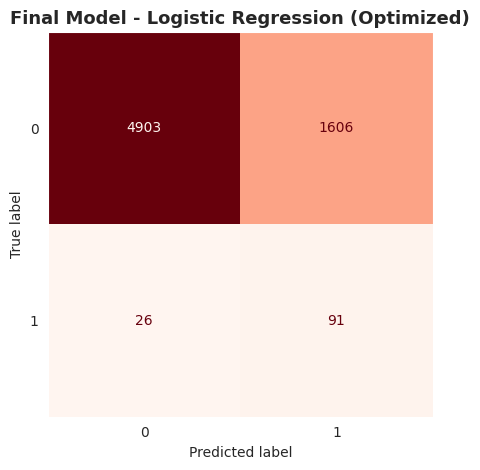

In [41]:
# -------------------------
# 1. Features & target
# -------------------------
X = df_cleaned.drop(columns=["target", 'image_name',
                             'patient_id','lesion_id',
                             'image_path', 'benign_malignant',
                             'diagnosis'])

y = df_cleaned["target"]

# -------------------------
# 2. Train-test split
# -------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------
# 3. Feature Selection
# -------------------------
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=200) # Select top 200 most informative features (empirically chosen to balance performance and dimensionality)

X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)


# -------------------------
# 4. Controlled Oversampling
# -------------------------
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(sampling_strategy=0.2, random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_sel, y_train)

# -------------------------
# 5. Scaling
# -------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test_sel)

# -------------------------
# 6. Train Logistic Regression
# -------------------------
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # Class weighting further penalizes misclassification of melanoma cases
    n_jobs=-1,
    random_state=42
)

model.fit(X_train_scaled, y_train_res)

# -------------------------
# 7. Predict with tuned threshold
# -------------------------
import numpy as np

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# tuned threshold
threshold = 0.4 # Lower threshold to prioritize recall (detect more melanoma cases)
y_pred = (y_pred_proba > threshold).astype(int)

# -------------------------
# 8. Evaluation
# -------------------------
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, classification_report, confusion_matrix, average_precision_score
from sklearn.metrics import ConfusionMatrixDisplay

print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba), 3))
print("PR-AUC:", round(average_precision_score(y_test, y_pred_proba), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    cmap="Reds",
    colorbar=False
)

disp.ax_.set_title("Final Model - Logistic Regression (Optimized)", fontsize=13, weight='bold')
disp.ax_.grid(False)

plt.tight_layout()
plt.show()

### Cross-validation
Cross-validation is performed on the processed training data to provide an approximate estimate of model stability. While this does not fully prevent data leakage due to prior preprocessing steps, it still offers a useful indication of consistency across folds.

In [34]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train_res,
    cv=5,
    scoring='balanced_accuracy'
)

print("CV Balanced Accuracy:", cv_scores.mean())

CV Balanced Accuracy: 0.8175094048240996


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall Curve for Final Model')

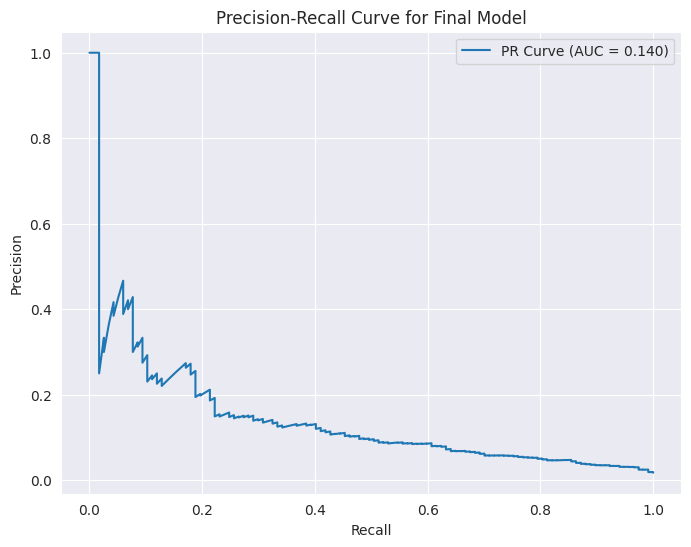

In [35]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Calculate precision and recall
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

# Plot the PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Final Model')
plt.legend()
plt.grid(True)
plt.show()

The Precision-Recall curve is especially important for this project because the dataset is highly imbalanced. It shows the trade-off between identifying melanoma cases (recall) and minimizing false positives (precision), providing a more realistic evaluation of performance for rare-event medical classification.

<Figure size 800x600 with 0 Axes>

(0.0, 1.0)

(0.0, 1.05)

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'Receiver Operating Characteristic (ROC) Curve')

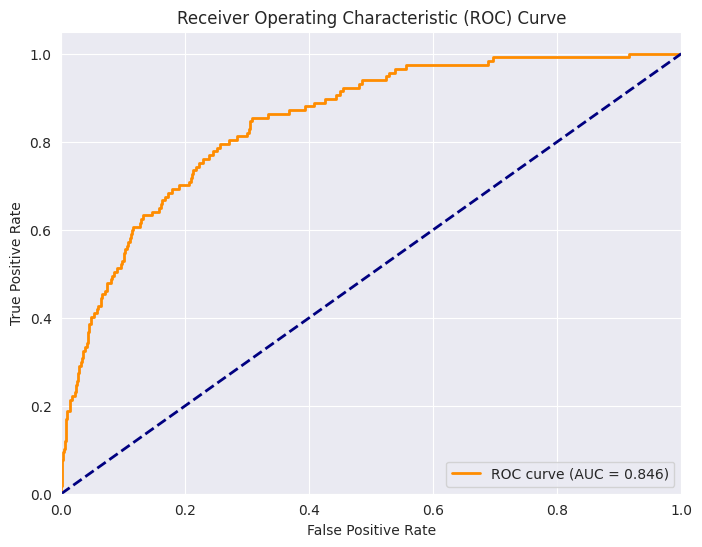

In [36]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve and ROC AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The ROC curve evaluates how well the model separates melanoma from benign lesions across different thresholds. The model achieved a ROC-AUC score of 0.846, indicating strong overall classification performance and good discrimination between classes.

## Final Model Development and Optimization

To improve performance, the final pipeline integrates **feature selection, imbalance handling, scaling, and threshold tuning**, based on insights from earlier experiments.

---

**Feature Selection (SelectKBest)**  
- Reduces noise from high-dimensional image embeddings  
- Improves generalization by retaining only the most informative features  

---

**Imbalance Handling (Hybrid Approach)**  
Combines **controlled oversampling (20%)** and **class weighting**:
- Oversampling increases minority representation without overfitting  
- Class weighting penalizes misclassification of melanoma cases  

This approach avoids risks associated with synthetic methods like SMOTE in high-dimensional spaces.

---

**Feature Scaling**  
- Ensures stable optimization and equal contribution of features  
- Essential for Logistic Regression performance  

---

**Threshold Tuning (0.4)**  
- Lowers the decision boundary to improve recall  
- Prioritizes detection of melanoma cases over default classification behavior  

---

### Performance Interpretation

The optimized model significantly improves **recall**, identifying a larger proportion of malignant cases. This comes at the cost of reduced precision, resulting in more false positives.

This trade-off is **intentional and appropriate** in a medical context:

- False negatives → high risk (missed diagnosis)  
- False positives → additional testing (acceptable)  

The model is therefore designed to prioritize **sensitivity over specificity**, aligning with clinical objectives.

---

### Limitations

- Low precision and F1-score indicate difficulty separating classes  
- Significant overlap in feature space between benign and malignant lesions  
- Extreme class imbalance continues to constrain performance  

**PR-AUC** is used as a key metric, providing a more realistic evaluation of performance on the minority class.

## Model Serialization and Deployment Preparation

In [ ]:
import joblib

deployment_bundle = {
    "model": model,
    "scaler": scaler,
    "selector": selector,
    "encoder": encoder,
    "threshold": 0.4
}

joblib.dump(deployment_bundle, "melanoma_pipeline.pkl")

print("Pipeline saved.")

['melanoma_pipeline.pkl']

Pipeline saved.


In [ ]:
import os

os.listdir()

['.config',
 'encoded_feature_order.pkl',
 'ISIC_2020_Training_GroundTruth_v2.csv',
 'image_features.csv',
 'melanoma_pipeline.pkl',
 'sample_data']

In [ ]:
import os

print(os.getcwd())

/content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Save final metadata encoded columns
encoded_feature_order = encoder.get_feature_names_out([
    "sex",
    "anatom_site_general_challenge"
])

joblib.dump(
    encoded_feature_order,
    "encoded_feature_order.pkl"
)

['encoded_feature_order.pkl']

In [ ]:
IMAGE_SIZE = (224, 224)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]